In [ ]:
import json 
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib.lines import Line2D

In [2]:
def summarize_hist(dir):
    with open(dir, 'r') as f:
        sim = json.load(f)
        
    sim = np.stack(sim)
    sim_mean = np.mean(sim, axis=0)
    
    sim_default_mean, sim_default_std = sim_mean[0], sim_mean[5]
    sim_lap_1_mean, sim_lap_1_std = sim_mean[1], sim_mean[6]
    sim_lap_2_mean, sim_lap_2_std = sim_mean[2], sim_mean[7]
    sim_iso_mean, sim_iso_std = sim_mean[3], sim_mean[8]
    sim_ep_mean, sim_ep_std = sim_mean[4], sim_mean[9]
    
    return sim_default_mean, sim_default_std, sim_lap_1_mean, sim_lap_1_std, \
            sim_lap_2_mean, sim_lap_2_std, sim_iso_mean, sim_iso_std, sim_ep_mean, sim_ep_std

In [3]:
# Load all data
data_default = summarize_hist('history/50_2_0_001_2024-08-28-02-03-57.json')

In [4]:
# Setup parameters
start_idx = 2
limit = 70
t_list = range(start_idx, limit)

plt.rc('font', size=18)          # controls default text sizes
plt.rc('axes', titlesize=20)     # fontsize of the axes title
plt.rc('axes', labelsize=20)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=15)    # fontsize of the tick labels
plt.rc('ytick', labelsize=15)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=20)  # fontsize of the figure title

plt.rcParams.update({
"text.usetex": True,
"font.family": "sans-serif",
"text.latex.preamble": r"\usepackage{amsmath}"
})

Text(0.1, 0.5, '$\\lvert \\mu_1^{(i)}-\\hat{\\mu}_1^{(i)} \\rvert$')

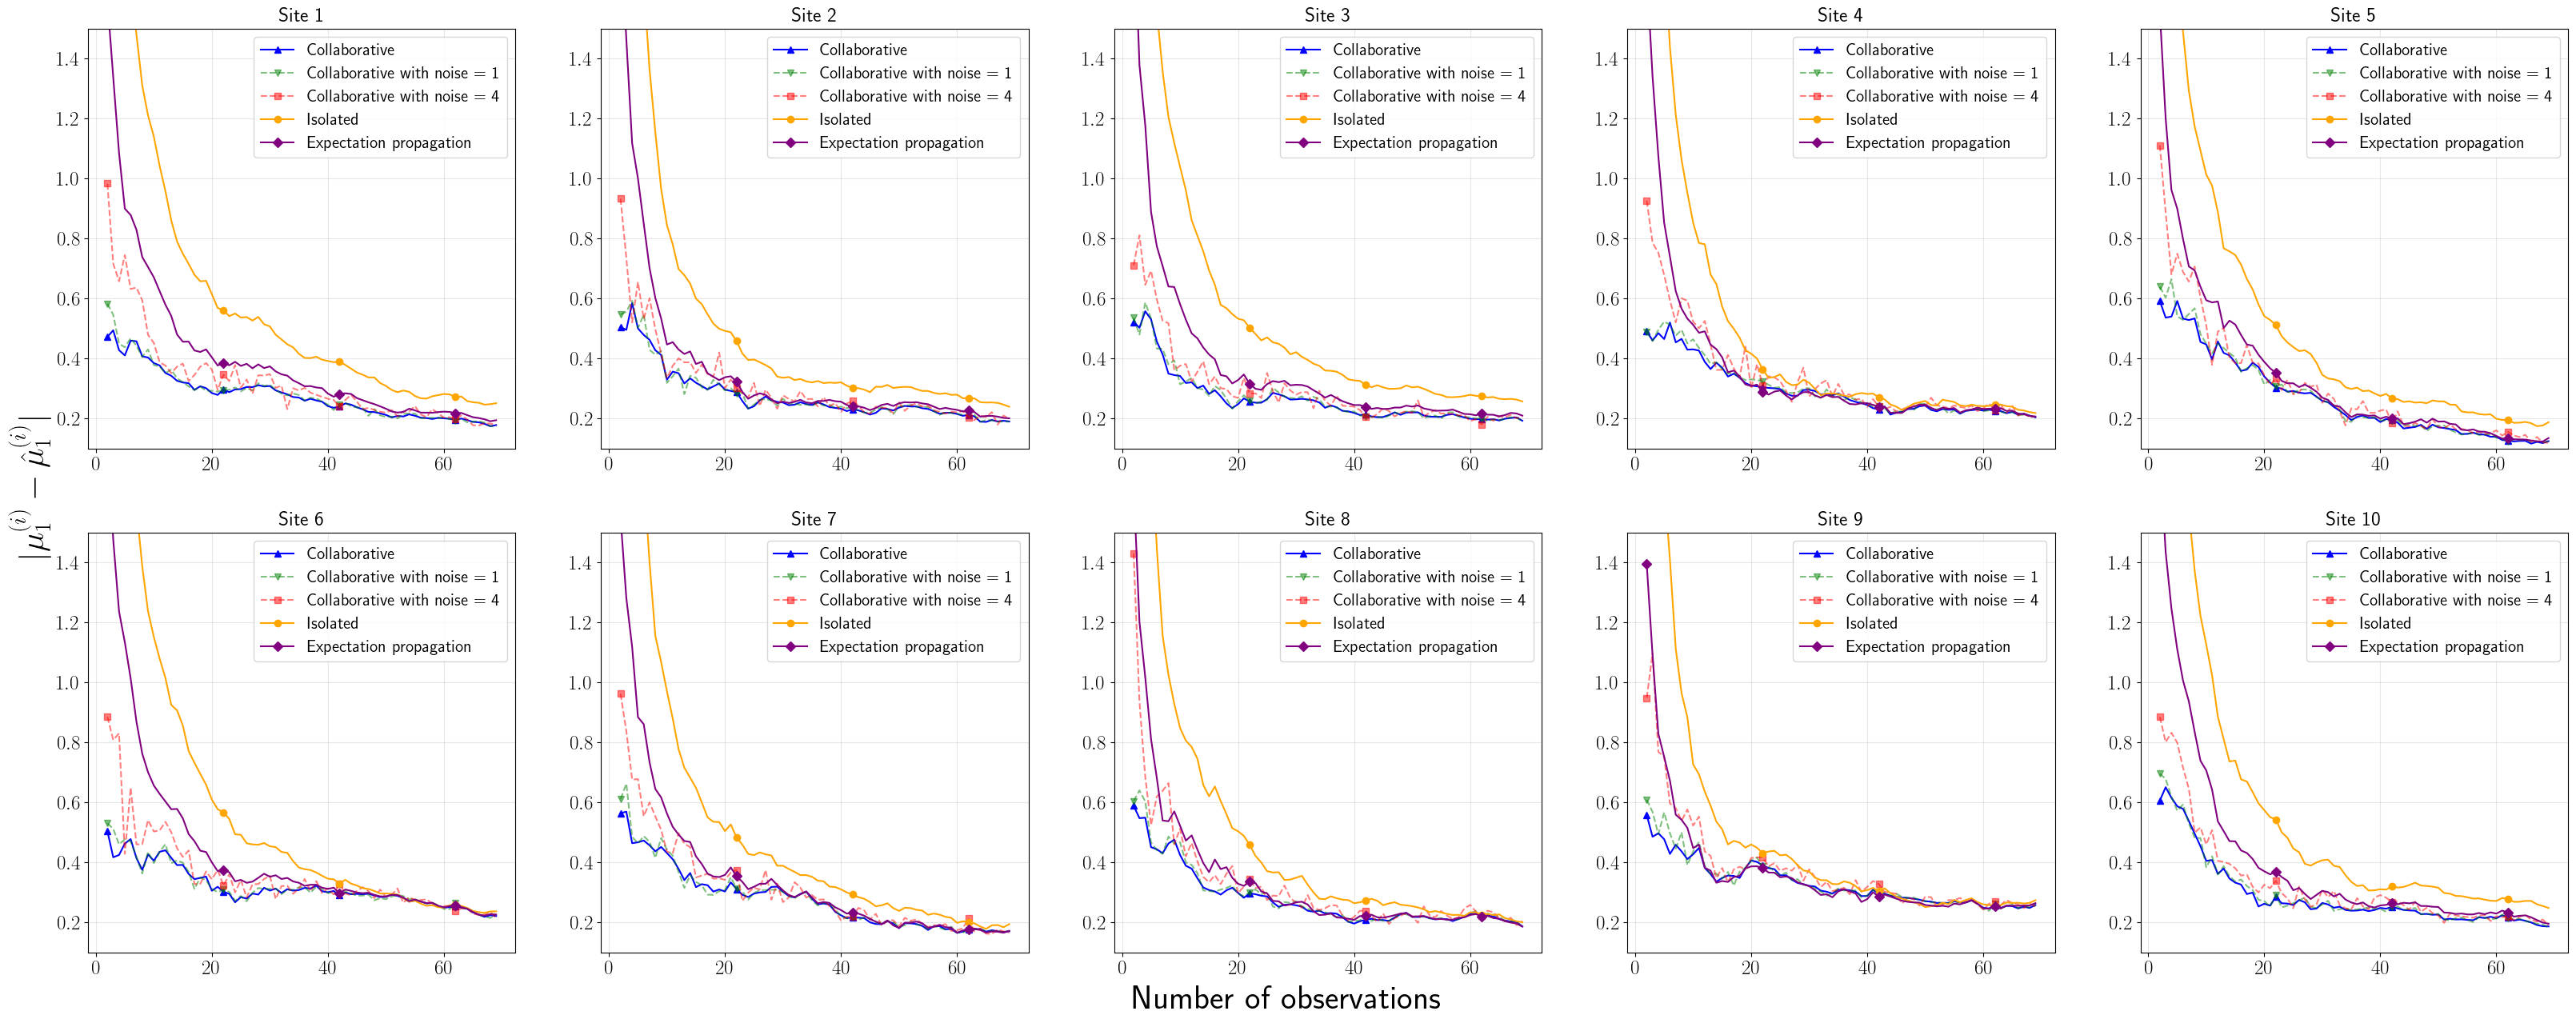

In [15]:
fig, ax = plt.subplots(2, 5, figsize=(40, 15))

# fig.supxlabel("Communication rounds")
# Plotting 10 sites
for i in range(10):        
    linear_line = data_default[0][i, start_idx:limit]
    linear_line_lap_1 = data_default[2][i, start_idx:limit]
    linear_line_lap_2 = data_default[4][i, start_idx:limit]
    linear_line_iso = data_default[6][i, start_idx:limit]
    linear_line_ep = data_default[8][i, start_idx:limit]

    ax[i // 5, i % 5].plot(t_list, linear_line, label="Collaborative", color='blue', marker='^', markevery=20)
    ax[i // 5, i % 5].plot(t_list, linear_line_lap_1, label="Collaborative with noise = 1", color='green', marker='v', linestyle='--', markevery=20, alpha=0.5)
    ax[i // 5, i % 5].plot(t_list, linear_line_lap_2, label="Collaborative with noise = 4", color='red', marker='s', linestyle='--', markevery=20, alpha=0.5)
    ax[i // 5, i % 5].plot(t_list, linear_line_iso, label="Isolated", color='orange', marker='o', markevery=20)
    ax[i // 5, i % 5].plot(t_list, linear_line_ep, label="Expectation propagation", color='purple', marker='D', markevery=20)
    #     ax[i//5, i%5].fill_between(t_list, linear_line - linear_line_std, linear_line + linear_line_std, color='blue', alpha=0.1)
    ax[i // 5, i % 5].grid(visible=True, alpha=0.3)
    ax[i // 5, i % 5].set_ylim([0.1, 1.5])
    ax[i // 5, i % 5].set_title(f'Site {i+1}')
    ax[i // 5, i % 5].legend()

ylabel = r'$\lvert \mu_1^{(i)}-\hat{\mu}_1^{(i)} \rvert$'
fig.text(0.5, 0.07, 'Number of observations', ha='center', va='center', fontsize=30)
fig.text(0.1, 0.5, ylabel , va='center', rotation='vertical', fontsize=30)

In [9]:
output_dir = f"figure/10site_30_2_"
jour = time.strftime("%Y-%m-%d-%H-%M-%S", time.localtime())
output_dir += jour

result_dir = output_dir + ".png"
fig.savefig(result_dir)

Text(0.07, 0.5, '$\\lvert \\hat{\\beta}^{(i)} - \\beta^{(i)} \\rvert$')

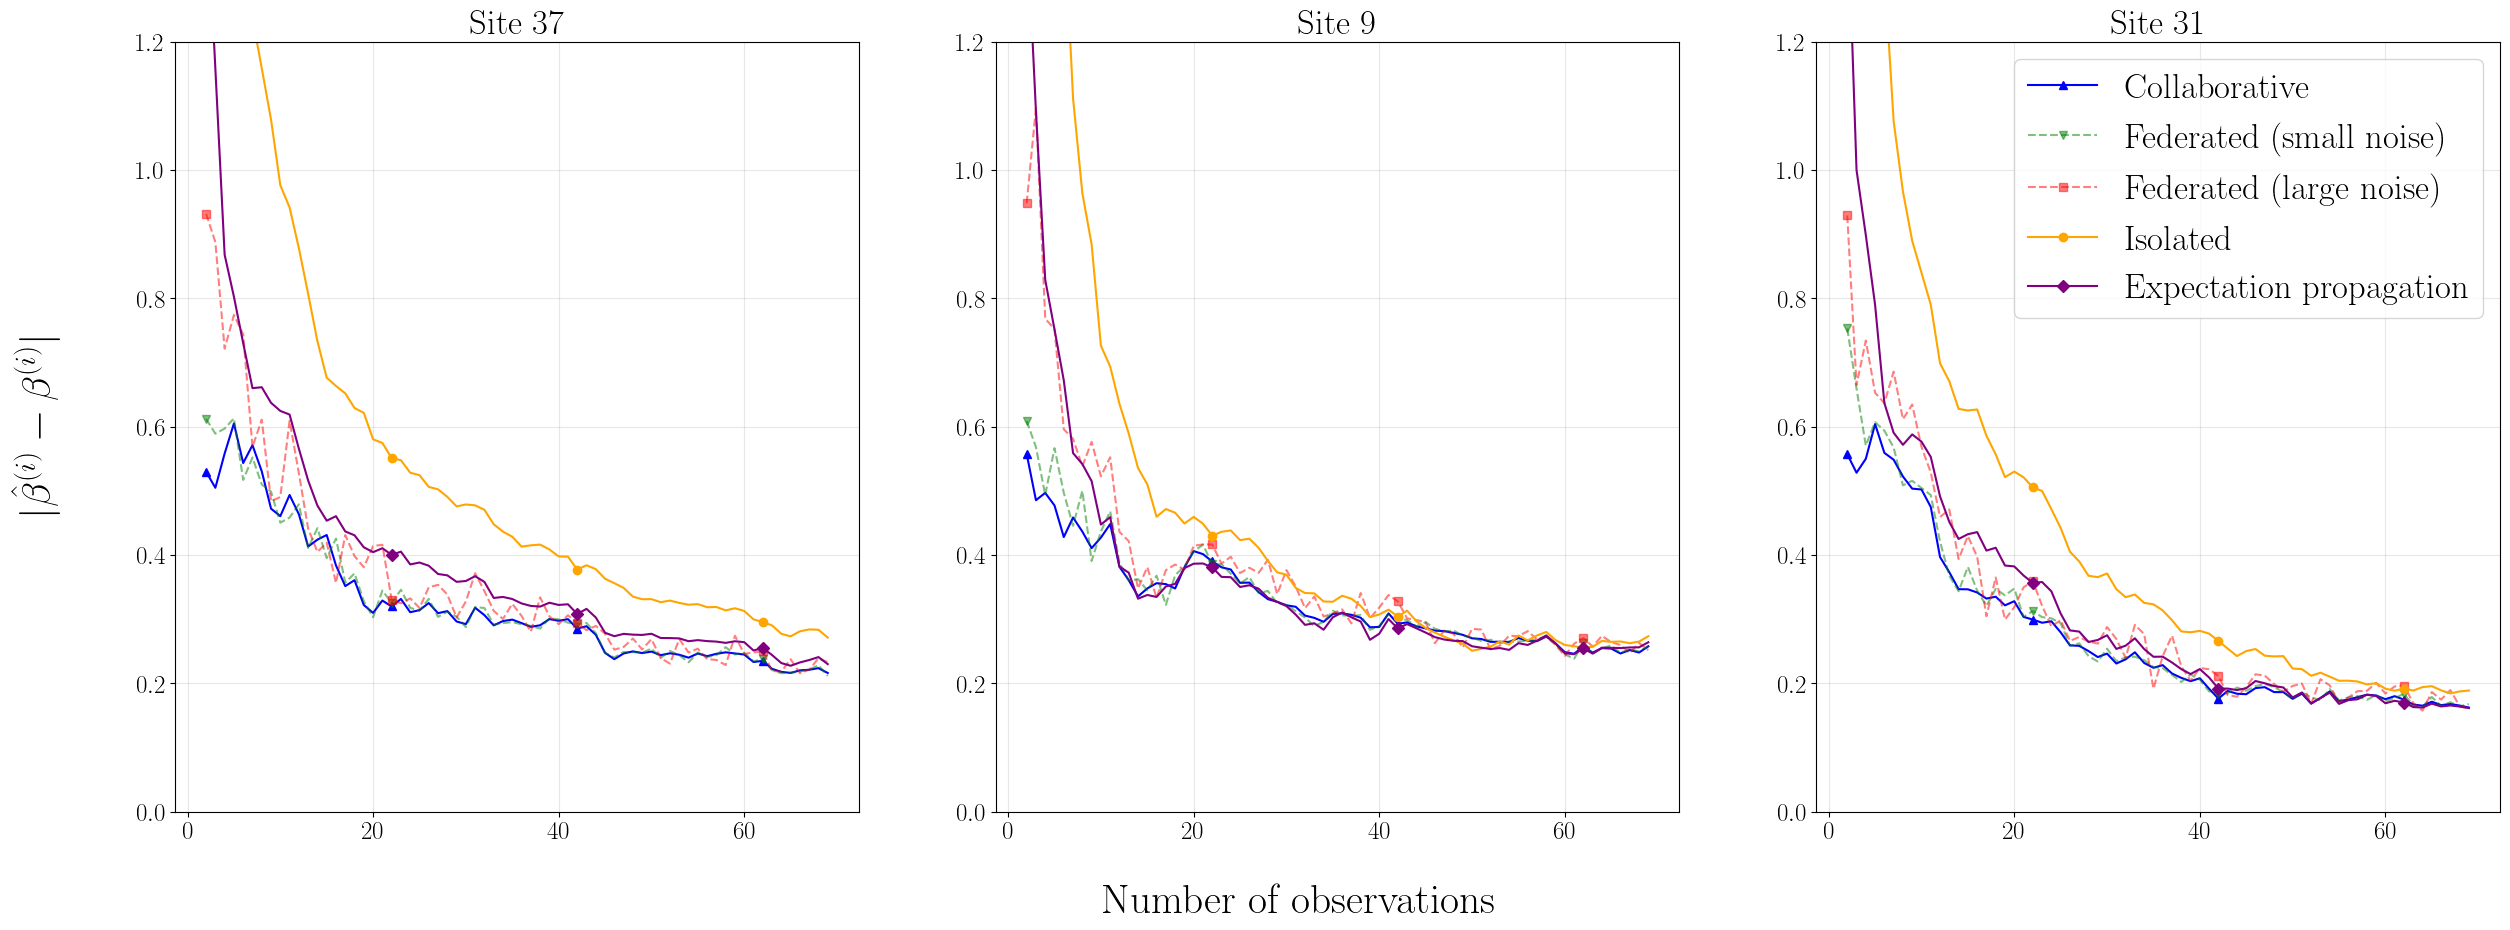

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(30, 10))
best_score_idx = np.argpartition(ep_score, 3)[:3]
start_idx = 2
limit = 70
t_list = range(start_idx, limit)
plt.rc('font', size=30)          # controls default text sizes
plt.rc('axes', titlesize=25)     # fontsize of the axes title
plt.rc('axes', labelsize=30)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=25)    # fontsize of the tick labels
plt.rc('ytick', labelsize=25)    # fontsize of the tick labels
plt.rc('legend', fontsize=25)    # legend fontsize
plt.rc('figure', titlesize=30)  # fontsize of the figure title

plt.rcParams.update({
"text.usetex": True,
"font.family": "serif",
"text.latex.preamble": r"\usepackage{amsmath}"
})

for j, i in enumerate(best_score_idx):
    linear_line = data_default[0][i, start_idx:limit]
    linear_line_lap_1 = data_default[2][i, start_idx:limit]
    linear_line_lap_2 = data_default[4][i, start_idx:limit]
    linear_line_iso = data_default[6][i, start_idx:limit]
    linear_line_ep = data_default[8][i, start_idx:limit]

    ax[j].plot(t_list, linear_line, label="Collaborative", color='blue', marker='^', markevery=20)
    ax[j].plot(t_list, linear_line_lap_1, label="Federated (small noise)", color='green', marker='v', linestyle='--', markevery=20, alpha=0.5)
    ax[j].plot(t_list, linear_line_lap_2, label="Federated (large noise)", color='red', marker='s', linestyle='--', markevery=20, alpha=0.5)
    ax[j].plot(t_list, linear_line_iso, label="Isolated", color='orange', marker='o', markevery=20)
    ax[j].plot(t_list, linear_line_ep, label="Expectation propagation", color='purple', marker='D', markevery=20)
#     ax[j].fill_between(t_list, linear_line - linear_std, linear_line + linear_std, color='blue', alpha=0.1)
    ax[j].grid(visible=True, alpha=0.3)
    ax[j].set_ylim([0, 1.2])
    ax[j].set_title(f'Site {i+1}')
ax[2].legend()

ylabel = r'$\lvert \hat{\beta}^{(i)} - \beta^{(i)} \rvert$'
fig.text(0.5, 0.02, 'Number of observations', ha='center', va='center', fontsize=30)
fig.text(0.07, 0.5, ylabel , va='center', rotation='vertical', fontsize=30)

In [12]:
output_dir = f"figure/3site_30_2_"
jour = time.strftime("%Y-%m-%d-%H-%M-%S", time.localtime())
output_dir += jour

result_dir = output_dir + ".png"
fig.savefig(result_dir)

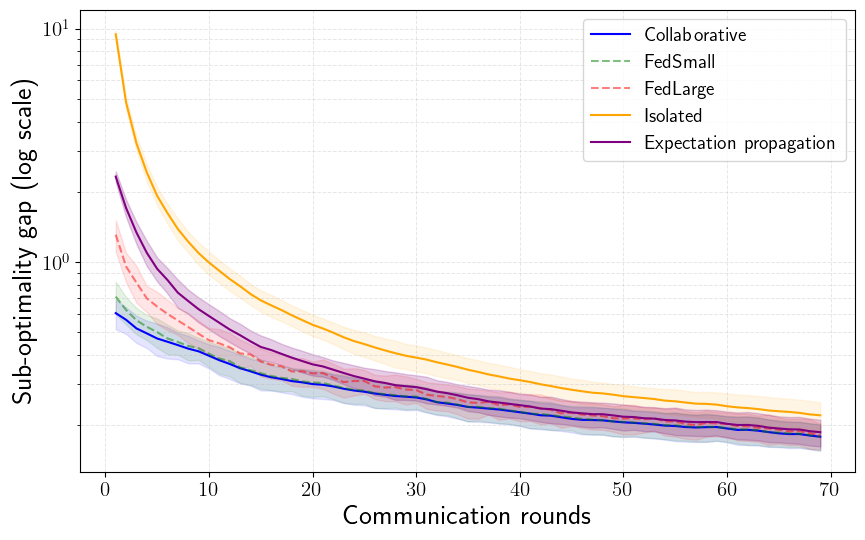

In [11]:
# 1 plot

SMALL_SIZE = 18
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc('font', size=18)          # controls default text sizes
plt.rc('axes', titlesize=20)     # fontsize of the axes title
plt.rc('axes', labelsize=20)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=15)    # fontsize of the tick labels
plt.rc('ytick', labelsize=15)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=20)  # fontsize of the figure title

start_idx=1
t_list = range(start_idx, limit)
    
lin_mean_hist_flat = np.mean(data_default[0], axis=0)
lin_lap_1_mean_hist_flat = np.mean(data_default[2], axis=0)
lin_lap_2_mean_hist_flat = np.mean(data_default[4], axis=0)
lin_iso_mean_hist_flat = np.mean(data_default[6], axis=0)
lin_ep_mean_hist_flat = np.mean(data_default[8], axis=0)

lin_std = np.std(data_default[0], axis=0)[start_idx:limit]
lin_lap_1_std = np.std(data_default[2], axis=0)[start_idx:limit]
lin_lap_2_std = np.std(data_default[4], axis=0)[start_idx:limit]
lin_iso_std = np.std(data_default[6], axis=0)[start_idx:limit]
lin_ep_std = np.std(data_default[8], axis=0)[start_idx:limit]

fig, ax = plt.subplots(figsize=(10,6))
linear_line = lin_mean_hist_flat[start_idx:limit]
linear_line_lap_1 = lin_lap_1_mean_hist_flat[start_idx:limit]
linear_line_lap_2 = lin_lap_2_mean_hist_flat[start_idx:limit]
linear_line_iso = lin_iso_mean_hist_flat[start_idx:limit]
linear_line_ep = lin_ep_mean_hist_flat[start_idx:limit]

ax.plot(t_list, linear_line, label="Collaborative", color='blue', markevery=20)
ax.plot(t_list, linear_line_lap_1, label="FedSmall", color='green', linestyle='--', markevery=20, alpha=0.5)
ax.plot(t_list, linear_line_lap_2, label="FedLarge", color='red', linestyle='--', markevery=20, alpha=0.5)
ax.plot(t_list, linear_line_iso, label="Isolated", color='orange', markevery=20)
ax.plot(t_list, linear_line_ep, label="Expectation propagation", color='purple', markevery=20)
ax.fill_between(t_list, linear_line - lin_std, linear_line + lin_std, color='blue', alpha=0.1)
ax.fill_between(t_list, linear_line_iso - lin_iso_std, linear_line_iso + lin_iso_std, color='orange', alpha=0.1)
ax.fill_between(t_list, linear_line_ep - lin_ep_std, linear_line_ep + lin_ep_std, color='purple', alpha=0.1)
ax.fill_between(t_list, linear_line_lap_1 - lin_lap_1_std, linear_line_lap_1 + lin_lap_1_std, color='green', alpha=0.1)
ax.fill_between(t_list, linear_line_lap_2 - lin_lap_2_std, linear_line_lap_2 + lin_lap_2_std, color='red', alpha=0.1)
ax.fill_between(t_list, linear_line_ep - lin_ep_std, linear_line_ep + lin_ep_std, color='purple', alpha=0.1)

ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.3)
# ax.set_ylim([10**(-0.75), 10**0.5])
ax.set_xlabel("Communication rounds")
# ax.set_ylabel(r'$\frac{\sum_{i=1}^N \lvert \hat{\beta}^{(i)} - \beta^{(i)} \rvert}{N} $', rotation=0, labelpad=55)
# ax[1].set_title(f'Average sub-optimality gap (log-scaled)')
ax.set_ylabel("Sub-optimality gap (log scale)")
ax.set_yscale('log')
ax.legend()

output_dir = f"figure/opt_gap_"
jour = time.strftime("%Y-%m-%d-%H-%M-%S", time.localtime())
output_dir += jour

result_dir = output_dir + ".png"
fig.savefig(result_dir, bbox_inches='tight')

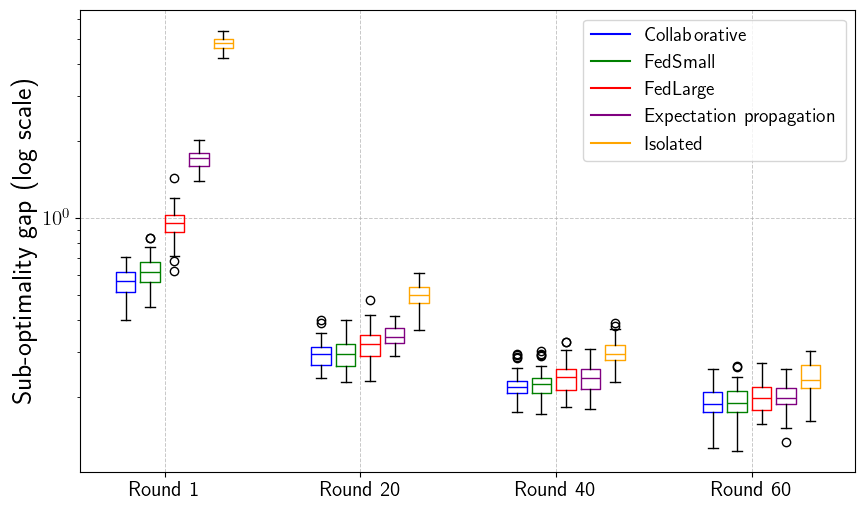

In [ ]:
# Define the periods and the number of boxplots per period
periods = [0, 20, 40, 60]
num_boxplots_per_period = 5

SMALL_SIZE = 18
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc('font', size=18)          # controls default text sizes
plt.rc('axes', titlesize=20)     # fontsize of the axes title
plt.rc('axes', labelsize=20)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=15)    # fontsize of the tick labels
plt.rc('ytick', labelsize=15)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=20)  # fontsize of the figure title

# Generate some dummy data for the boxplots
np.random.seed(42)  # For reproducibility
data = []

for i in range(4):
    data.append(data_default[0][:, i*20+start_idx])
    data.append(data_default[2][:, i*20+start_idx])
    data.append(data_default[4][:, i*20+start_idx])
    data.append(data_default[8][:, i*20+start_idx])
    data.append(data_default[6][:, i*20+start_idx])

# Define the width of the groups and the individual boxplots
group_width = 10
bar_width = group_width / num_boxplots_per_period
inner_gap = 0.5  # Gap between boxplots within each period

# Create positions for each boxplot
positions = []
for period in periods:
    base_position = period - group_width / 2
    for i in range(num_boxplots_per_period):
        positions.append(base_position + i * (bar_width + inner_gap) + bar_width / 2)

# Plot average opt gap
fig, ax = plt.subplots(figsize=(10, 6))
legend_elem = [Line2D([0], [0], color='blue', label="Collaborative"),
               Line2D([0], [0], color='green', label="FedSmall"),
               Line2D([0], [0], color='red', label="FedLarge"),
               Line2D([0], [0], color='purple', label="Expectation propagation"),
               Line2D([0], [0], color='orange', label="Isolated"),]

cols = ['blue', 'green', 'red', 'purple', 'orange']*5
# Plot avg opt gap with log-scale
box = ax.boxplot(data, positions=positions, widths=bar_width)
for median, box_frame, col in zip(box['medians'], box['boxes'], cols):
    median.set_color(col)
    box_frame.set_color(col)
ax.set_ylabel("Sub-optimality gap (log scale)")
# ax.set_ylabel(r'$\frac{\sum_{i=1}^N \lvert \hat{\beta}^{(i)} - \beta^{(i)} \rvert}{N} $', rotation=0, labelpad=55)
# ax.set_title('Average sub-optimality gap (log scale)')

ax.set_xticks(periods)
ax.set_xticklabels(['Round 1', 'Round 20', 'Round 40', 'Round 60'])
ax.set_yscale('log')
ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(handles=legend_elem, loc='upper right')

# Show the plot
plt.show()

output_dir = f"figure/opt_gap_var_"
jour = time.strftime("%Y-%m-%d-%H-%M-%S", time.localtime())
output_dir += jour

result_dir = output_dir + ".png"
fig.savefig(result_dir, bbox_inches='tight')

In [ ]:
# Define the periods and the number of boxplots per period
periods = [0, 20, 40, 60]
num_boxplots_per_period = 5

# Generate some dummy data for the boxplots
np.random.seed(42)  # For reproducibility
data = [np.random.rand(10) * 10 for _ in range(len(periods) * num_boxplots_per_period)]

# Define the width of the groups and the individual boxplots
group_width = 10
bar_width = group_width / num_boxplots_per_period
inner_gap = 0.5  # Gap between boxplots within each period

# Create positions for each boxplot
positions = []
for period in periods:
    base_position = period - group_width / 2
    for i in range(num_boxplots_per_period):
        positions.append(base_position + i * (bar_width + inner_gap) + bar_width / 2)

# Plot the boxplots
fig, ax = plt.subplots()
ax.boxplot(data, positions=positions, widths=bar_width)

# Add labels and title
ax.set_xlabel('Period')
ax.set_ylabel('Value')
ax.set_title('Boxplots in 4 Periods with Internal Gaps')

# Set x-ticks to the center of each period
ax.set_xticks(periods)
ax.set_xticklabels(['Period 1', 'Period 2', 'Period 3', 'Period 4'])

# Show the plot
plt.show()

In [ ]:
output_dir = f"figure/1site_30_2_"
jour = time.strftime("%Y-%m-%d-%H-%M-%S", time.localtime())
output_dir += jour

result_dir = output_dir + ".png"
fig.savefig(result_dir)

In [ ]:
N = [9, 24, 48]
for n in N:
    print(f"n = {n+1} | default mean = {linear_line[n]:.6f} | iso mean = {linear_line_iso[n]:.6f} | small = {linear_line_lap_1[n]:.6f} | large = {linear_line_lap_2[n]:.6f} | ep = {linear_line_ep[n]:.6f}")
    print(f"n = {n+1} | default std = {lin_std[n]:.6f} | iso mean = {lin_iso_std[n]:.6f} | small = {lin_lap_1_std[n]:.6f} | large = {lin_lap_2_std[n]:.6f} | ep = {lin_ep_std[n]:.6f}")
    print('-'*30)
    